# CGPA, Internships and Placement Analysis

I wanted to check something people say a lot around placements - "if your CGPA is good, you
will get placed and get a good salary". This notebook uses a dataset of 1000 students
(CGPA, Internships, Placed, Salary) to actually check if that is true, instead of just
assuming it.

Steps in this notebook:
1. Load and clean the data
2. Explore the data with some charts
3. Check correlation between CGPA/Internships and Salary
4. Build a model to predict if a student gets placed
5. Build a model to predict salary
6. Write down the conclusion


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, confusion_matrix
)

sns.set_style("whitegrid")
pd.set_option("display.precision", 2)


## 1. Load the data

In [2]:
df = pd.read_csv("Placement.csv")
print(df.shape)
df.head()


(1000, 5)


,Student_ID,CGPA,Internships,Placed,Salary (INR LPA)
0,1,7.90,3,Yes,17.63
1,2,7.39,0,Yes,28.37
2,3,8.02,2,Yes,8.95
3,4,8.72,4,Yes,22.59
4,5,7.31,2,Yes,19.67


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        1000 non-null   int64  
 1   CGPA              1000 non-null   float64
 2   Internships       1000 non-null   int64  
 3   Placed            1000 non-null   object 
 4   Salary (INR LPA)  1000 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 39.2+ KB


In [4]:
df.describe()


,Student_ID,CGPA,Internships,Salary (INR LPA)
count,1000.00,1000.00,1000.00,1000.00
mean,500.50,7.52,2.04,11.80
std,288.82,0.78,1.42,10.11
min,1.00,4.91,0.00,0.00
25%,250.75,6.98,1.00,0.00
50%,500.50,7.52,2.00,11.71
75%,750.25,8.02,3.00,20.93
max,1000.00,10.58,4.00,29.90


## 2. Check the data quality

In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nZero values in numeric columns:")
print((df.select_dtypes("number") == 0).sum())


Missing values:
Student_ID          0
CGPA                0
Internships         0
Placed              0
Salary (INR LPA)    0
dtype: int64

Duplicate rows: 0

Zero values in numeric columns:
Student_ID            0
CGPA                  0
Internships         191
Salary (INR LPA)    310
dtype: int64


`Salary (INR LPA)` has 310 zero values. There are also exactly 310 students with
`Placed = No`. So the 0 salary is not bad/missing data - it just means the student was not
placed, so they don't have a salary.

In [6]:
zero_salary = (df["Salary (INR LPA)"] == 0).sum()
not_placed = (df["Placed"] == "No").sum()
print(zero_salary, not_placed, zero_salary == not_placed)


310 310 True


## 3. Cleaning

- `Student_ID` is just a row number, it doesn't help in prediction, so I am dropping it.
- Keeping `Internships` and `Placed` since they might actually matter.
- Adding a numeric column `Placed_num` (1 = Yes, 0 = No) so it can be used in models.

In [7]:
data = df.drop(columns=["Student_ID"]).copy()
data["Placed_num"] = data["Placed"].map({"Yes": 1, "No": 0})
data.to_csv("Placement_clean.csv", index=False)
data.head()


,CGPA,Internships,Placed,Salary (INR LPA),Placed_num
0,7.90,3,Yes,17.63,1
1,7.39,0,Yes,28.37,1
2,8.02,2,Yes,8.95,1
3,8.72,4,Yes,22.59,1
4,7.31,2,Yes,19.67,1


## 4. Exploratory Data Analysis

### How many students got placed?

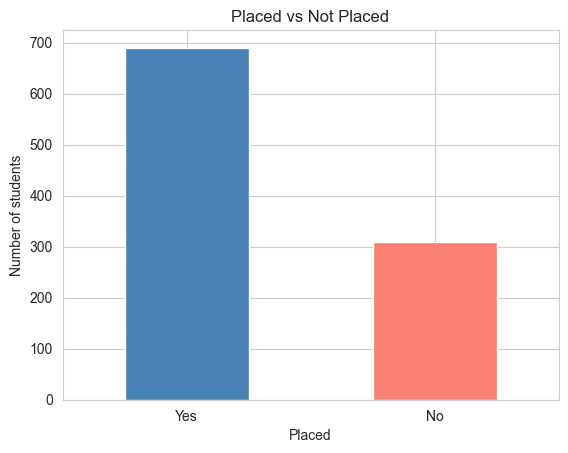

Placed
Yes    69.0
No     31.0
Name: proportion, dtype: float64


In [8]:
counts = data["Placed"].value_counts()
counts.plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Placed vs Not Placed")
plt.ylabel("Number of students")
plt.xticks(rotation=0)
plt.savefig("assets/placement_rate.png", dpi=150, bbox_inches="tight")
plt.show()

print(data["Placed"].value_counts(normalize=True) * 100)


### CGPA distribution

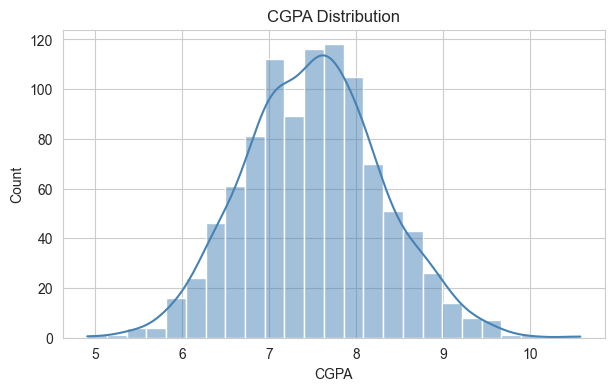

In [9]:
plt.figure(figsize=(7, 4))
sns.histplot(data["CGPA"], bins=25, kde=True, color="steelblue")
plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.show()


### Does CGPA differ for placed vs not placed students?

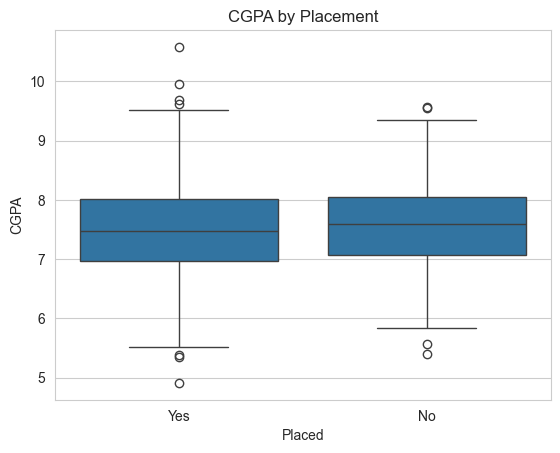

Placed
No     7.57
Yes    7.49
Name: CGPA, dtype: float64


In [10]:
sns.boxplot(data=data, x="Placed", y="CGPA")
plt.title("CGPA by Placement")
plt.show()

print(data.groupby("Placed")["CGPA"].mean())


The average CGPA of placed and not-placed students is almost the same. So just from this,
CGPA does not look like it makes much of a difference.

### Does the number of internships change placement chances?

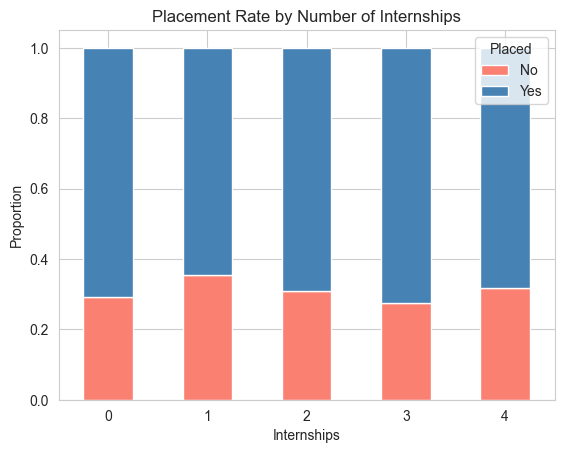

In [11]:
placement_by_internship = pd.crosstab(data["Internships"], data["Placed"], normalize="index")
placement_by_internship.plot(kind="bar", stacked=True, color=["salmon", "steelblue"])
plt.title("Placement Rate by Number of Internships")
plt.ylabel("Proportion")
plt.xlabel("Internships")
plt.xticks(rotation=0)
plt.show()


The proportion of placed students looks about the same no matter how many internships a
student did. So internships also don't seem to be changing placement chances much here.

### Correlation between CGPA, Internships and Salary

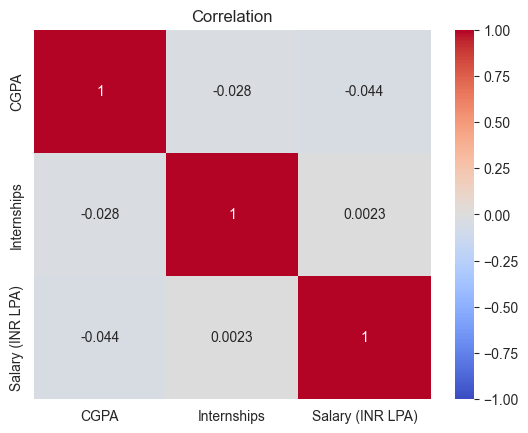

In [12]:
corr = data[["CGPA", "Internships", "Salary (INR LPA)"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation")
plt.show()


All the correlation values are very close to 0. In simple terms, that means there is
basically no straight-line relationship between CGPA/Internships and Salary in this data.

### CGPA vs Salary (only placed students)

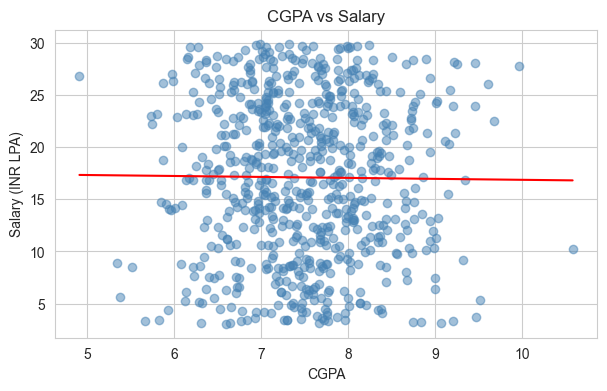

correlation: -0.01  p-value: 0.799


In [13]:
placed = data[data["Placed"] == "Yes"]

plt.figure(figsize=(7, 4))
plt.scatter(placed["CGPA"], placed["Salary (INR LPA)"], alpha=0.5, color="steelblue")

z = np.polyfit(placed["CGPA"], placed["Salary (INR LPA)"], 1)
x_line = np.linspace(placed["CGPA"].min(), placed["CGPA"].max(), 100)
plt.plot(x_line, np.polyval(z, x_line), color="red")

plt.xlabel("CGPA")
plt.ylabel("Salary (INR LPA)")
plt.title("CGPA vs Salary")
plt.savefig("assets/cgpa_vs_salary.png", dpi=150, bbox_inches="tight")
plt.show()

r_value, p_value = stats.pearsonr(placed["CGPA"], placed["Salary (INR LPA)"])
print("correlation:", round(r_value, 3), " p-value:", round(p_value, 3))


The red line (trend line) is almost flat, and the p-value is way more than 0.05. That
means this relationship is not statistically significant - basically CGPA is not really telling
us anything about salary here.

## 5. Predicting Placement (Classification)

Before training any model, it's good to know what a simple guess would score. About 69% of
students are placed, so if I just guess "placed" for every single student, I would already be
right 69% of the time. A real model needs to beat this to actually be useful.

In [14]:
X = data[["CGPA", "Internships"]]
y = data["Placed_num"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

guess_everyone_placed = round(y_test.mean() * 100, 1)
print("Accuracy if we just guess everyone is placed:", guess_everyone_placed, "%")


Accuracy if we just guess everyone is placed: 69.0 %


In [15]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
pred_log = log_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)

print("Logistic Regression accuracy:", round(accuracy_score(y_test, pred_log), 3))
print("Random Forest accuracy:", round(accuracy_score(y_test, pred_rf), 3))


Logistic Regression accuracy: 0.69
Random Forest accuracy: 0.675


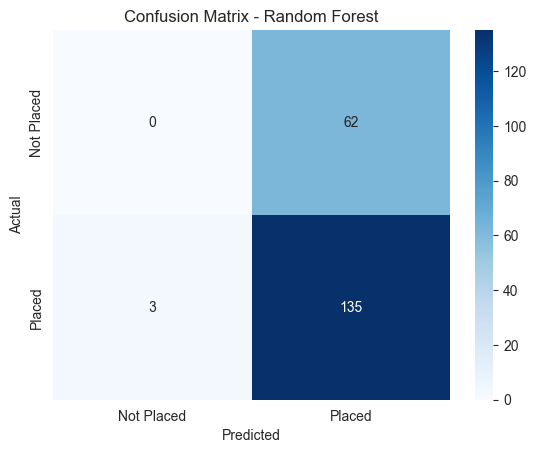

In [16]:
cm = confusion_matrix(y_test, pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Placed", "Placed"], yticklabels=["Not Placed", "Placed"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.savefig("assets/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


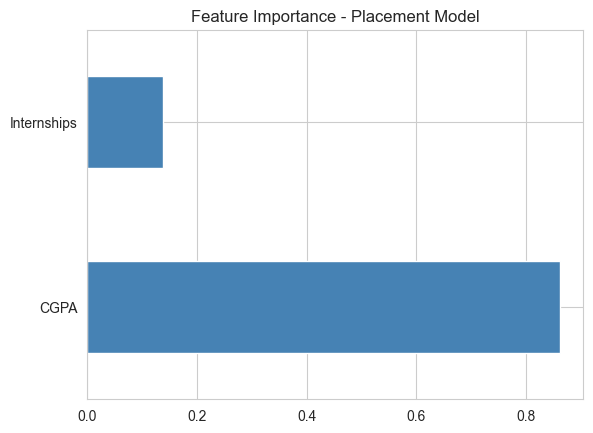

In [17]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.plot(kind="barh", color="steelblue")
plt.title("Feature Importance - Placement Model")
plt.show()


Both models score around 69%, which is basically the same as just guessing "placed" for
everyone. So the models aren't really learning anything useful from CGPA and Internships - these
two features are not enough to tell who gets placed.

## 6. Predicting Salary (Regression)

Using only the placed students for this part, since salary doesn't really exist for someone who
wasn't placed.

In [18]:
X2 = placed[["CGPA", "Internships"]]
y2 = placed["Salary (INR LPA)"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

print("Average salary in training data:", round(y2_train.mean(), 2))


Average salary in training data: 17.18


In [19]:
lin_model = LinearRegression()
lin_model.fit(X2_train, y2_train)
pred_lin = lin_model.predict(X2_test)

rf_reg = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf_reg.fit(X2_train, y2_train)
pred_rf_reg = rf_reg.predict(X2_test)

for name, pred in [("Linear Regression", pred_lin), ("Random Forest", pred_rf_reg)]:
    mae = mean_absolute_error(y2_test, pred)
    rmse = mean_squared_error(y2_test, pred) ** 0.5
    r2 = r2_score(y2_test, pred)
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.3f}")


Linear Regression -> MAE: 6.42, RMSE: 7.42, R2: -0.004
Random Forest -> MAE: 6.65, RMSE: 7.72, R2: -0.088


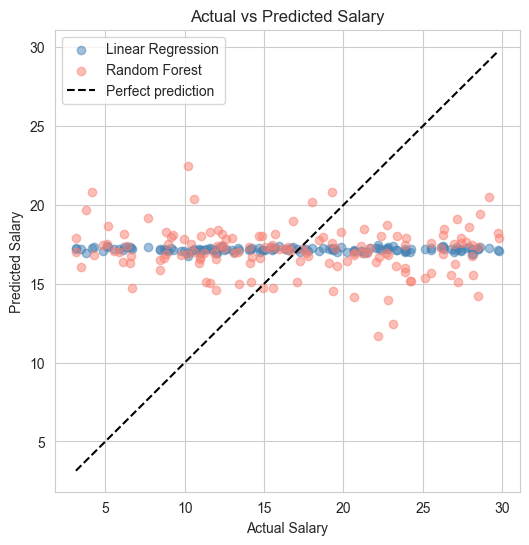

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(y2_test, pred_lin, alpha=0.5, label="Linear Regression", color="steelblue")
plt.scatter(y2_test, pred_rf_reg, alpha=0.5, label="Random Forest", color="salmon")

lims = [y2_test.min(), y2_test.max()]
plt.plot(lims, lims, "k--", label="Perfect prediction")

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.legend()
plt.savefig("assets/actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()


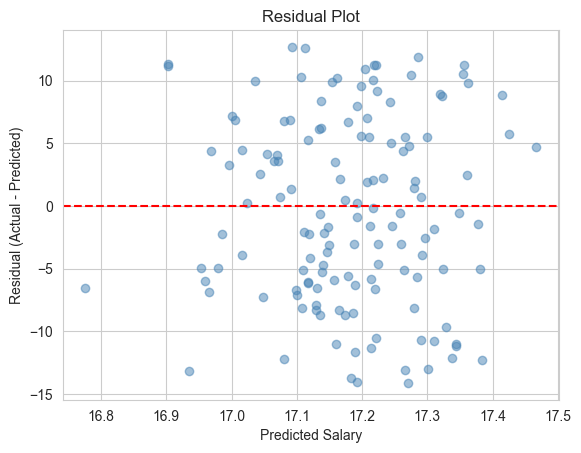

In [21]:
residuals = y2_test - pred_lin

plt.scatter(pred_lin, residuals, alpha=0.5, color="steelblue")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Salary")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()


The R2 score is close to 0 (and even negative for the random forest model), which means
this model is not really doing better than just guessing the average salary for everyone. The
"actual vs predicted" plot also shows the predicted points sitting in almost a flat line while
the real salary values are spread out all over - the model just isn't finding a real pattern to
use.

## 7. Conclusion

What I found from this dataset:

- Average CGPA is almost the same for placed and not-placed students
- Placement rate doesn't really change with number of internships
- Correlation between CGPA and Salary is close to 0
- The placement model does not beat the simple "guess everyone is placed" baseline
- The salary model does not beat the simple "guess the average salary" baseline

So, in this dataset, CGPA and internship count alone are not good predictors of placement or
salary. This doesn't mean CGPA never matters at all, it just means these two features by
themselves are not enough to explain the outcome here. In real life, things like skills,
aptitude test scores, communication, and interview performance probably matter a lot more. To
actually build a good prediction model, more features like these would be needed.

Tools used: Python, pandas, numpy, matplotlib, seaborn, scikit-learn, scipy.
